In [470]:
import pandas as pd
import numpy as np
from typing import Dict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
import matplotlib.pyplot as plt

from scipy import stats

# Data Exploration

In [471]:
df: pd.DataFrame = pd.read_csv("../data/salary_data.csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [472]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [473]:
print(df.info())
print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    str    
 2   Education Level      373 non-null    str    
 3   Job Title            373 non-null    str    
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), str(3)
memory usage: 17.7 KB
None
(375, 6)


In [474]:
df.isna().any()

Age                    True
Gender                 True
Education Level        True
Job Title              True
Years of Experience    True
Salary                 True
dtype: bool

# Data Cleaning

In [475]:
df.dropna(inplace=True)
df.shape

(373, 6)

In [476]:
df.info()

<class 'pandas.DataFrame'>
Index: 373 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    str    
 2   Education Level      373 non-null    str    
 3   Job Title            373 non-null    str    
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), str(3)
memory usage: 20.4 KB


In [477]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [478]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [479]:
df["Salary"].shape

(373,)

# Pre-training model

In [480]:
X = df.drop(columns=['Salary'])
y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [481]:
categorical_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

In [482]:
p1 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

p2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVR(C=0.1, max_iter=10000))
])

In [483]:
def fit_and_print(X):
    X.fit(X_train, y_train)
    y_pred = X.predict(X_test)
    mae = f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}"
    mse =  f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}"
    r2 =  f"R Squared: {r2_score(y_test, y_pred)}"


    return mae, mse, r2

print(fit_and_print(p1))

print(fit_and_print(p2))

('Mean Absolute Error: 11596.521058222766', 'Mean Squared Error: 354248539.00767475', 'R Squared: 0.8522475952130909')
('Mean Absolute Error: 40530.267855946644', 'Mean Squared Error: 2453002737.7854395', 'R Squared: -0.023115167876015752')


# GridSearch and Fine tuning

In [484]:
params_p1 = [{
    'model__fit_intercept': [True, False],
    'model__n_jobs': [1, 5, 10, 15, None],
    'model__positive': [True, False],
}]


params_p2 = [{
    'model__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'model__degree': [1,2,3,4],
    'model__gamma': ['scale', 'auto'],
    'model__C': [0.1, 1, 10, 100, 1000],
    'model__epsilon': [0.01, 0.1, 0.5, 1],
    'model__max_iter': [1000, 5000, 10000]
}]

In [485]:
def grid_search(pipeline, pe):
    clf = GridSearchCV(pipeline, param_grid=pe, scoring='r2', cv=5)
    clf.fit(X_train,y_train)
    best_model = clf.best_estimator_    
    return best_model

model = grid_search(p2, params_p2)
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

# Evaluation

In [486]:
def model_evaluation(model):
    y_pred = model.predict(X_test)
    mae = f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}"
    mse =  f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}"
    r2 =  f"R Squared: {r2_score(y_test, y_pred)}"
    rmse = f"Root Mean Squared Error: {root_mean_squared_error(y_test, y_pred)}"
    return mae, mse, r2, rmse

In [487]:
model_evaluation(model)

('Mean Absolute Error: 9551.662783310558',
 'Mean Squared Error: 207487802.4325507',
 'R Squared: 0.9134595675137103',
 'Root Mean Squared Error: 14404.436900918783')

In [488]:
def rand_search(param, X_train, y_train):
    random_search = RandomizedSearchCV(estimator=model,
    param_distributions=param, n_iter=10, cv=5)
    besty_model = random_search.fit(X_train, y_train)
    return besty_model

e = rand_search(params_p2, X_train, y_train)

e.best_params_

model_evaluation(e)

('Mean Absolute Error: 9551.588161090256',
 'Mean Squared Error: 207489373.83717743',
 'R Squared: 0.9134589121015154',
 'Root Mean Squared Error: 14404.491446669592')

('Mean Absolute Error: 9551.588161090256', 'Mean Squared Error: 207489373.83717743', 'R Squared: 0.9134589121015154', 'Root Mean Squared Error: 14404.491446669592')


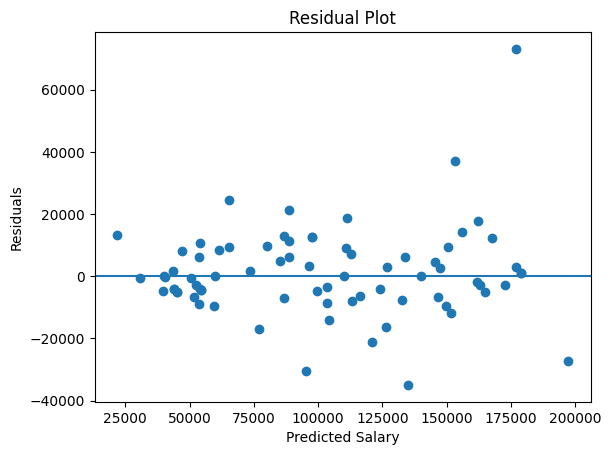

Evaluation completed.


In [489]:
def basic_model_evaluation(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}"
    mse =  f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}"
    r2 =  f"R Squared: {r2_score(y_test, y_pred)}"
    rmse = f"Root Mean Squared Error: {root_mean_squared_error(y_test, y_pred)}"
    return mae, mse, r2, rmse

def plot_residual(model, X_test, y_test):
    y_pred = model.predict(X_test)
    residual = y_test - y_pred
    plt.scatter(y_pred, residual)
    plt.axhline(0)
    plt.title("Residual Plot")
    plt.xlabel("Predicted Salary")
    plt.ylabel("Residuals")
    plt.show()
    return

def model_evaluation_offical(model, X_test, y_test):
    userInput = input("Would you like to run a basic evaluation again? (y/n): ")
    if userInput.lower() == "y":
         print(basic_model_evaluation(model, X_test, y_test))
    elif userInput.lower() == "n":
        pass    
    else:
        print("Invalid input.")
    
    userInput2 = input("Would you like to run see a visual representation? (y/n): ")
    if userInput2.lower() == "y":
         plot_residual(model, X_test, y_test)
 
    print("Evaluation completed.")
    return
    

model_evaluation_offical(e, X_test, y_test)